# Peramalan Harga Saham INDF — CNN-BiLSTM
**Revisi sesuai bimbingan 20-04-2026**

Perubahan dari versi sebelumnya:
- Grid parameter diperluas ke 3 nilai (16, 32, 64) untuk insight lebih kaya
- Dropout: [0.1, 0.2, 0.3] (3 nilai)
- Layer BiLSTM: [1, 2] (tetap)
- EPOCHS = 80 + EarlyStopping (efisien, berhenti otomatis di epoch stasioner) --> masi agak ragu kalo 30 karna ada yang epochnya 100 dan dibawha 60.
- Windowing dilakukan dari data gabungan agar konteks antar segmen terjaga
- Normalisasi tetap dipakai (diperlukan untuk kestabilan training deep learning)
- Inverse transform digunakan untuk mengembalikan prediksi ke satuan Rupiah
- Visualisasi prediksi vs aktual: hanya 1 grafik terbaik
- Label kategori akurasi (Sangat Akurat/Akurat) dihapus

## CELL 1 — Pra-Pemrosesan Data

--- ANALISIS AWAL DATA MENTAH ---
Total Hari Kerja Seharusnya : 2609 hari
Total Data Tersedia         : 2415 hari
Jumlah Data Hilang          : 194 hari


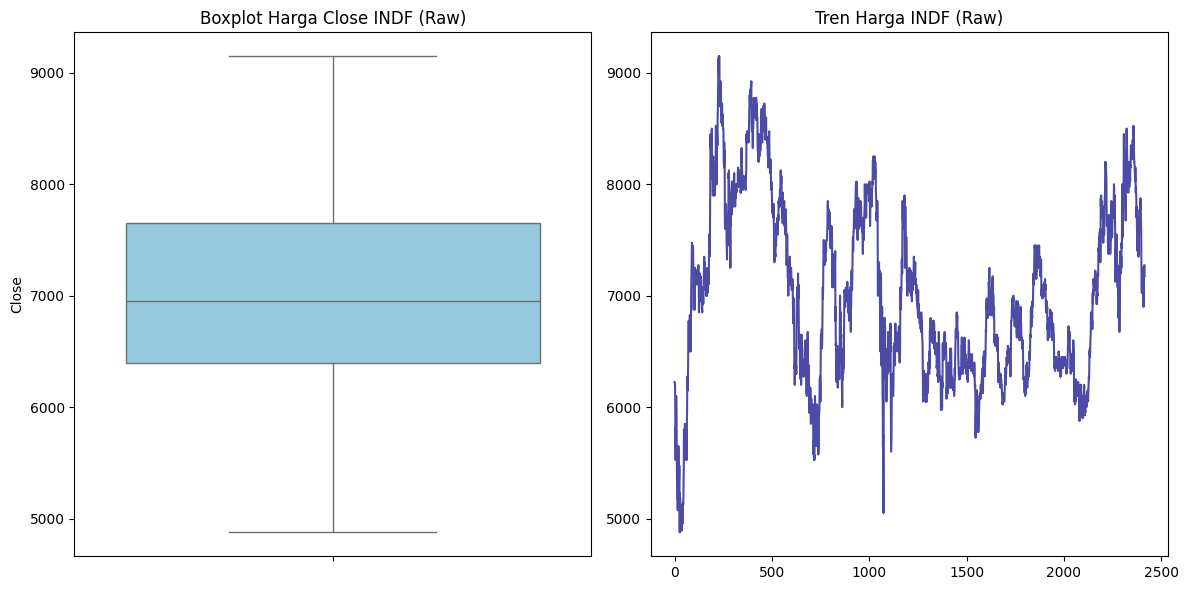


--- HASIL DETEKSI OUTLIER ---
Q1: 6400.0 | Q3: 7650.0 | IQR: 1250.0
Batas Bawah: 4525.0 | Batas Atas: 9525.0
Jumlah Outliers Terdeteksi: 0

✅ Tidak ditemukan outliers pada data mentah.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA & STANDARISASI KOLOM
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df = df_raw[['Tanggal', 'Terakhir']].rename(columns={'Tanggal': 'Date', 'Terakhir': 'Close'})

# 2. FORMAT TANGGAL & SORTIR
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')
df = df.drop_duplicates(subset=['Date'], keep='first')

# 3. IDENTIFIKASI MISSING VALUES (Business Days)
all_business_days = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='B')
missing_dates = all_business_days.difference(df['Date'])

print(f"--- ANALISIS AWAL DATA MENTAH ---")
print(f"Total Hari Kerja Seharusnya : {len(all_business_days)} hari")
print(f"Total Data Tersedia         : {len(df)} hari")
print(f"Jumlah Data Hilang          : {len(missing_dates)} hari")

# 4. DETEKSI OUTLIERS
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(y=df['Close'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Harga Close INDF (Raw)')
axes[1].plot(df.index, df['Close'], color='navy', alpha=0.7)
axes[1].set_title('Tren Harga INDF (Raw)')
plt.tight_layout()
plt.show()

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print(f"\n--- HASIL DETEKSI OUTLIER ---")
print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Batas Bawah: {lower_bound} | Batas Atas: {upper_bound}")
print(f"Jumlah Outliers Terdeteksi: {len(outliers)}")
if len(outliers) > 0:
    print("\nDaftar Tanggal Outliers:")
    print(outliers)
else:
    print("\n✅ Tidak ditemukan outliers pada data mentah.")

|| MEMBUAT LIST TANGGAL YANG HILANG / MISSING VALUE ||

In [2]:
import pandas as pd

# 1. Load data mentah
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df_raw['Tanggal'] = pd.to_datetime(df_raw['Tanggal'], format='%d/%m/%Y')
df_raw = df_raw.sort_values('Tanggal')

# 2. Buat rentang hari kerja (Senin-Jumat) dari tanggal awal sampai akhir
full_range = pd.date_range(start=df_raw['Tanggal'].min(), end=df_raw['Tanggal'].max(), freq='B')

# 3. Cari tanggal yang ada di kalender hari kerja tapi tidak ada di dataset
missing_dates = full_range.difference(df_raw['Tanggal'])

# 4. Tampilkan hasil dalam bentuk tabel
missing_dates_df = pd.DataFrame(missing_dates, columns=['Tanggal_Kosong'])
missing_dates_df['Hari'] = missing_dates_df['Tanggal_Kosong'].dt.day_name() # Nama hari dalam Bahasa Inggris

print(f"Total Tanggal yang Hilang: {len(missing_dates_df)} hari")
print("\n--- 20 Tanggal Pertama yang Kosong ---")
print(missing_dates_df.head(20))

# Simpan ke CSV jika Anda ingin melihat daftar lengkapnya (194 hari)
missing_dates_df.to_csv('daftar_tanggal_kosong.csv', index=False)

Total Tanggal yang Hilang: 194 hari

--- 20 Tanggal Pertama yang Kosong ---
   Tanggal_Kosong       Hari
0      2015-12-09  Wednesday
1      2015-12-24   Thursday
2      2015-12-25     Friday
3      2015-12-31   Thursday
4      2016-01-01     Friday
5      2016-02-08     Monday
6      2016-03-09  Wednesday
7      2016-03-25     Friday
8      2016-05-05   Thursday
9      2016-05-06     Friday
10     2016-07-04     Monday
11     2016-07-05    Tuesday
12     2016-07-06  Wednesday
13     2016-07-07   Thursday
14     2016-07-08     Friday
15     2016-08-17  Wednesday
16     2016-09-12     Monday
17     2016-12-12     Monday
18     2016-12-26     Monday
19     2017-01-02     Monday


In [7]:
# Install semua library yang dibutuhkan
%pip install scikit-learn tensorflow pandas numpy matplotlib seaborn 

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 388.9 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 461.0 kB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
   ---------------------------------------- 0.0/435.2 kB ? eta -:--:--
   ---------- ----------------------------- 112.6/435.2 kB 3.3 MB/s eta 0:00:01
   ----------------------- ---------------- 256.0/435.2 kB 3.2 MB/s eta 0:00:01
   ---------------------------------------  430.1/435.2 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 435.2/435.2 kB 3.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ortools 9.14.6206 requires protobuf<6.32,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from sklearn.preprocessing import MinMaxScaler

# 5. REINDEXING & INTERPOLASI
df_indexed = df.set_index('Date')
all_business_days = pd.date_range(start=df_indexed.index.min(), end=df_indexed.index.max(), freq='B')
df_complete = df_indexed.reindex(all_business_days)

# Interpolasi Polinomial Ordo 2
df_complete['Close'] = df_complete['Close'].interpolate(method='polynomial', order=2)
df_complete['Close'] = df_complete['Close'].ffill().bfill()

# 6. NORMALISASI
# Catatan: Normalisasi tetap digunakan meskipun univariate karena membantu
# kestabilan gradient descent pada deep learning (nilai input terbatas 0-1).
# Hasil prediksi akan di-inverse transform kembali ke satuan Rupiah.
scaler_global = MinMaxScaler(feature_range=(0, 1))
df_complete['Close_Scaled'] = scaler_global.fit_transform(df_complete[['Close']])

# Simpan hasil
df_final = df_complete.reset_index().rename(columns={'index': 'Date'})
df_final.to_csv('INDF_Cleaned.csv', index=False)

print(f"✅ Pra-pemrosesan Selesai!")
print(f"Total Baris Akhir : {len(df_final)}")
print(f"Rentang Tanggal   : {df_final['Date'].min()} s/d {df_final['Date'].max()}")
print(f"Data disimpan ke  : 'INDF_Cleaned.csv'")
print(df_final.head())

✅ Pra-pemrosesan Selesai!
Total Baris Akhir : 2609
Rentang Tanggal   : 2015-10-23 00:00:00 s/d 2025-10-22 00:00:00
Data disimpan ke  : 'INDF_Cleaned.csv'
        Date   Close  Close_Scaled
0 2015-10-23  6225.0      0.315789
1 2015-10-26  6225.0      0.315789
2 2015-10-27  6200.0      0.309942
3 2015-10-28  6075.0      0.280702
4 2015-10-29  5650.0      0.181287


## CELL 3 — Load Data & Fungsi Windowing

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# Load data bersih
df = pd.read_csv('INDF_Cleaned.csv', parse_dates=['Date'], index_col='Date')
data_full = df[['Close']].values   # Gunakan harga asli (Rupiah)

# Parameter tetap
WINDOW_SIZE = 30

def create_window_dataset(dataset, lookback):
    """Membuat pasangan (X, y) dari data time series dengan sliding window."""
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

# ==========================================
# INTI: FUNGSI PEMBAGI SKENARIO
# ==========================================
def jalankan_skenario(ratio_train, ratio_val, ratio_test):
    """
    Membagi data, normalisasi, lalu windowing dari data gabungan
    agar konteks antar segmen (train→val→test) tetap terjaga.

    Alur:
      1. Split data mentah (Close) → train / val / test
      2. Fit scaler HANYA pada train → transform val & test
      3. Gabungkan kembali → window dari full scaled
      4. Potong window hasil menjadi 3 bagian sesuai proporsi
    """
    label = f"{int(ratio_train*100)}-{int(ratio_val*100)}-{int(ratio_test*100)}"
    print(f"\n>>> MEMPERSIAPKAN SKENARIO {label} ...")

    n       = len(data_full)
    n_train = int(ratio_train * n)
    n_val   = int(ratio_val   * n)
    n_test  = n - n_train - n_val

    # 1. Split data mentah
    train_raw = data_full[:n_train]
    val_raw   = data_full[n_train : n_train + n_val]
    test_raw  = data_full[n_train + n_val :]

    # 2. Normalisasi — fit HANYA pada train (cegah data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    # 3. Gabungkan untuk windowing (konteks antar segmen terjaga)
    full_scaled = np.concatenate([train_scaled, val_scaled, test_scaled])
    X_all, y_all = create_window_dataset(full_scaled, WINDOW_SIZE)

    # 4. Potong kembali sesuai proporsi
    # Jumlah window yang "dimiliki" tiap segmen:
    #   - Train menghasilkan (n_train - WINDOW_SIZE) window
    #   - Val & Test masing-masing menghasilkan n_val dan n_test window
    #     (mereka "meminjam" WINDOW_SIZE terakhir dari segmen sebelumnya sebagai konteks)
    n_train_w = n_train - WINDOW_SIZE
    n_val_w   = n_val
    # n_test_w  = n_test (sisa)

    X_train = X_all[:n_train_w]
    y_train = y_all[:n_train_w]

    X_val   = X_all[n_train_w : n_train_w + n_val_w]
    y_val   = y_all[n_train_w : n_train_w + n_val_w]

    X_test  = X_all[n_train_w + n_val_w :]
    y_test  = y_all[n_train_w + n_val_w :]

    print(f"   Total data      : {n} baris")
    print(f"   Train (mentah)  : {n_train} | Val: {n_val} | Test: {n_test}")
    print(f"   Shape X_train   : {X_train.shape}")
    print(f"   Shape X_val     : {X_val.shape}")
    print(f"   Shape X_test    : {X_test.shape}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val'  : X_val,   'y_val'  : y_val,
        'X_test' : X_test,  'y_test' : y_test,
        'scaler' : scaler
    }

# ==========================================
# EKSEKUSI 3 SKENARIO
# ==========================================
# List skenario: (Train, Val, Test)
skenario_list = [
    (0.80, 0.10, 0.10),
    (0.70, 0.15, 0.15),
    (0.60, 0.20, 0.20)
]

# Dictionary untuk menyimpan semua data siap pakai
datasets = {}

for r_train, r_val, r_test in skenario_list:
    nama = f"{int(r_train*100)}-{int(r_val*100)}-{int(r_test*100)}"
    datasets[nama] = jalankan_skenario(r_train, r_val, r_test)

print("\n✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']")


>>> MEMPERSIAPKAN SKENARIO 80-10-10 ...
   Total data      : 2609 baris
   Train (mentah)  : 2087 | Val: 260 | Test: 262
   Shape X_train   : (2057, 30, 1)
   Shape X_val     : (260, 30, 1)
   Shape X_test    : (262, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 70-15-15 ...
   Total data      : 2609 baris
   Train (mentah)  : 1826 | Val: 391 | Test: 392
   Shape X_train   : (1796, 30, 1)
   Shape X_val     : (391, 30, 1)
   Shape X_test    : (392, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 60-20-20 ...
   Total data      : 2609 baris
   Train (mentah)  : 1565 | Val: 521 | Test: 523
   Shape X_train   : (1535, 30, 1)
   Shape X_val     : (521, 30, 1)
   Shape X_test    : (523, 30, 1)

✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']


## CELL 5 - Definisi Arsitektur Model CNN-BiLSTM

In [5]:
# ============================================================
# CELL 5 — DEFINISI ARSITEKTUR MODEL CNN-BiLSTM
# ============================================================
# Lanjutan dari cell pembagian dataset (datasets sudah tersedia)

import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Bidirectional,
                                     LSTM, Dense, Dropout, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.random.set_seed(42)
np.random.seed(42)

# ----------------------------------------------------------
# FUNGSI BANGUN MODEL CNN-BiLSTM
# Parameter yang bisa di-tuning:
#   - n_filters     : jumlah filter Conv1D
#   - n_units       : jumlah unit BiLSTM per layer
#   - n_bilstm_layers : jumlah layer BiLSTM (1 atau 2)
#   - dropout_rate  : dropout untuk regularisasi
# ----------------------------------------------------------
def bangun_model(window_size, n_filters, n_units, n_bilstm_layers, dropout_rate):
    """
    Membangun model CNN-BiLSTM.
    Arsitektur:
      Conv1D → MaxPooling1D → Dropout
      → BiLSTM (1 atau 2 layer)
      → Dense(1) output
    """
    model = Sequential(name=f"CNN_BiLSTM_f{n_filters}_u{n_units}_l{n_bilstm_layers}")

    # === LAYER CNN — ekstrak pola lokal jangka pendek ===
    model.add(Conv1D(filters=n_filters,
                     kernel_size=3,
                     activation='relu',
                     padding='same',
                     input_shape=(window_size, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(dropout_rate))


    # === LAYER BiLSTM — tangkap dependensi temporal dua arah ===
    if n_bilstm_layers == 1:
        model.add(Bidirectional(LSTM(n_units, return_sequences=False)))
        model.add(Dropout(dropout_rate))
    else:
        model.add(Bidirectional(LSTM(n_units, return_sequences=True)))
        model.add(Dropout(dropout_rate))
        model.add(Bidirectional(LSTM(n_units // 2, return_sequences=False)))
        model.add(Dropout(dropout_rate))

    # === OUTPUT LAYER ===
    model.add(Dense(1))

    # Compile dengan optimizer Adam & loss MSE (sesuai proposal)
    model.compile(optimizer='adam', loss='mse')
    
    return model

def hitung_metrik(y_true_scaled, y_pred_scaled, scaler):
    """
    Menghitung MAE, RMSE, MAPE setelah inverse transform
    sehingga metrik dalam satuan asli (Rupiah).
    """
    # Inverse transform: kembalikan ke satuan Rupiah
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, rmse, mape


print("✅ Fungsi model dan metrik siap digunakan.")


✅ Fungsi model dan metrik siap digunakan.


## CELL 6 — Hyperparameter Tuning (Grid Search)

**Revisi grid parameter:**
- `n_filters` & `n_units` → 3 nilai [16, 32, 64] agar insight lebih kaya (bukan linier)
- `dropout_rate` → [0.1, 0.2, 0.3] (3 nilai)
- `n_bilstm_layers` → [1, 2] (tetap)
- Total: 3 × 3 × 2 × 3 = **54 kombinasi**

Tuning dilakukan pada **skenario 80-10-10** sebagai benchmark.

In [6]:
from itertools import product
import os

# --- GRID PARAMETER (REVISI) ---
param_grid = {
    'n_filters'       : [16, 32, 64],   # 3 nilai → insight titik optimal
    'n_units'         : [16, 32, 64],   # 3 nilai → insight titik optimal
    'n_bilstm_layers' : [1, 2],         # 2 nilai (cukup)
    'dropout_rate'    : [0.1, 0.2, 0.3], # 3 nilai
}

# --- PARAMETER TRAINING ---
# EPOCHS=80: EarlyStopping akan berhenti otomatis di epoch stasioner.
# Dari hasil sebelumnya epoch stasioner rata-rata <60, jadi 80 sudah cukup
# sebagai batas atas tanpa membuang waktu komputasi.
EPOCHS     = 80
BATCH_SIZE = 32
PATIENCE   = 10   # Berhenti jika val_loss tidak membaik selama 10 epoch

# Pakai skenario 80-10-10 sebagai benchmark tuning
data_tuning = datasets['80-10-10']
X_train = data_tuning['X_train']
y_train = data_tuning['y_train']
X_val   = data_tuning['X_val']
y_val   = data_tuning['y_val']
X_test  = data_tuning['X_test']
y_test  = data_tuning['y_test']
scaler  = data_tuning['scaler']

kombinasi = list(product(
    param_grid['n_filters'],
    param_grid['n_units'],
    param_grid['n_bilstm_layers'],
    param_grid['dropout_rate']
))

total = len(kombinasi)
print("=" * 70)
print("  HYPERPARAMETER TUNING CNN-BiLSTM")
print(f"  Skenario: 80-10-10 | Window: {WINDOW_SIZE} hari | Total kombinasi: {total}")
print("=" * 70)

hasil_tuning = []

for idx, (n_filters, n_units, n_layers, dropout) in enumerate(kombinasi, 1):
    nama = f"f{n_filters}_u{n_units}_l{n_layers}_d{int(dropout*10)}"
    print(f"[{idx:02d}/{total}] {nama} — Filter={n_filters}, Unit={n_units}, "
          f"Layer={n_layers}, Dropout={dropout} ...", end=' ')

    model = bangun_model(
        window_size    = WINDOW_SIZE,
        n_filters      = n_filters,
        n_units        = n_units,
        n_bilstm_layers= n_layers,
        dropout_rate   = dropout
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=0
    )

    waktu_mulai = time.time()
    history = model.fit(
        X_train, y_train,
        epochs          = EPOCHS,
        batch_size      = BATCH_SIZE,
        validation_data = (X_val, y_val),
        callbacks       = [early_stop],
        verbose         = 0
    )
    durasi_detik   = time.time() - waktu_mulai
    durasi_menit   = durasi_detik / 60
    epoch_berhenti = len(history.history['loss'])

    # Evaluasi performa dari TEST SET
    y_pred = model.predict(X_test, verbose=0)
    mae, rmse, mape = hitung_metrik(y_test, y_pred, scaler)

    hasil_tuning.append({
        'Nama'          : nama,
        'Filter CNN'    : n_filters,
        'Unit BiLSTM'   : n_units,
        'Layer BiLSTM'  : n_layers,
        'Dropout'       : dropout,
        'Epoch Berhenti': epoch_berhenti,
        'Waktu (detik)' : round(durasi_detik, 2),
        'Waktu (menit)' : round(durasi_menit, 2),
        'MAE'           : round(mae, 4),
        'RMSE'          : round(rmse, 4),
        'MAPE (%)'      : round(mape, 4),
    })

    print(f"Epoch: {epoch_berhenti} | Waktu: {durasi_menit:.2f} mnt | MAPE: {mape:.4f}%")

df_tuning = pd.DataFrame(hasil_tuning)

print("\n" + "=" * 70)
print("  REKAP HASIL TUNING (diurutkan MAPE terkecil)")
print("=" * 70)
print(df_tuning.sort_values('MAPE (%)').to_string(index=False))

df_tuning.to_csv('hasil_tuning_CNN_BiLSTM.csv', index=False)
print("\n✅ Hasil tuning disimpan ke: 'hasil_tuning_CNN_BiLSTM.csv'")

  HYPERPARAMETER TUNING CNN-BiLSTM
  Skenario: 80-10-10 | Window: 30 hari | Total kombinasi: 54
[01/54] f16_u16_l1_d1 — Filter=16, Unit=16, Layer=1, Dropout=0.1 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 42 | Waktu: 0.58 mnt | MAPE: 1.9217%
[02/54] f16_u16_l1_d2 — Filter=16, Unit=16, Layer=1, Dropout=0.2 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 38 | Waktu: 0.53 mnt | MAPE: 1.9765%
[03/54] f16_u16_l1_d3 — Filter=16, Unit=16, Layer=1, Dropout=0.3 ... 

...

Epoch: 44 | Waktu: 1.23 mnt | MAPE: 1.5963%
[53/54] f64_u64_l2_d2 — Filter=64, Unit=64, Layer=2, Dropout=0.2 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 38 | Waktu: 0.94 mnt | MAPE: 1.8044%
[54/54] f64_u64_l2_d3 — Filter=64, Unit=64, Layer=2, Dropout=0.3 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 34 | Waktu: 0.80 mnt | MAPE: 1.8403%

  REKAP HASIL TUNING (diurutkan MAPE terkecil)
         Nama  Filter CNN  Unit BiLSTM  Layer BiLSTM  Dropout  Epoch Berhenti  Waktu (detik)  Waktu (menit)      MAE     RMSE  MAPE (%)
f64_u16_l1_d1          64           16             1      0.1              57          51.49           0.86 117.5465 169.3669    1.5369
f32_u64_l1_d1          32           64             1      0.1              33          38.44           0.64 119.1922 166.1683    1.5524
f64_u32_l2_d1          64           32             2      0.1              41          51.76           0.86 121.1586 171.0689    1.5818
f64_u32_l1_d1          64           32             1      0.1              44          46.72           0.78 121.4463 172.1616    1.5864
f64_u64_l2_d1          64           64             2      0.1              44          73.99           1.23 122.2087 174.4020    1.5963
f64_u32_l1_d2          64           32             1      0.2              66          65.13

## CELL 7 — Visualisasi Trade-Off Tuning

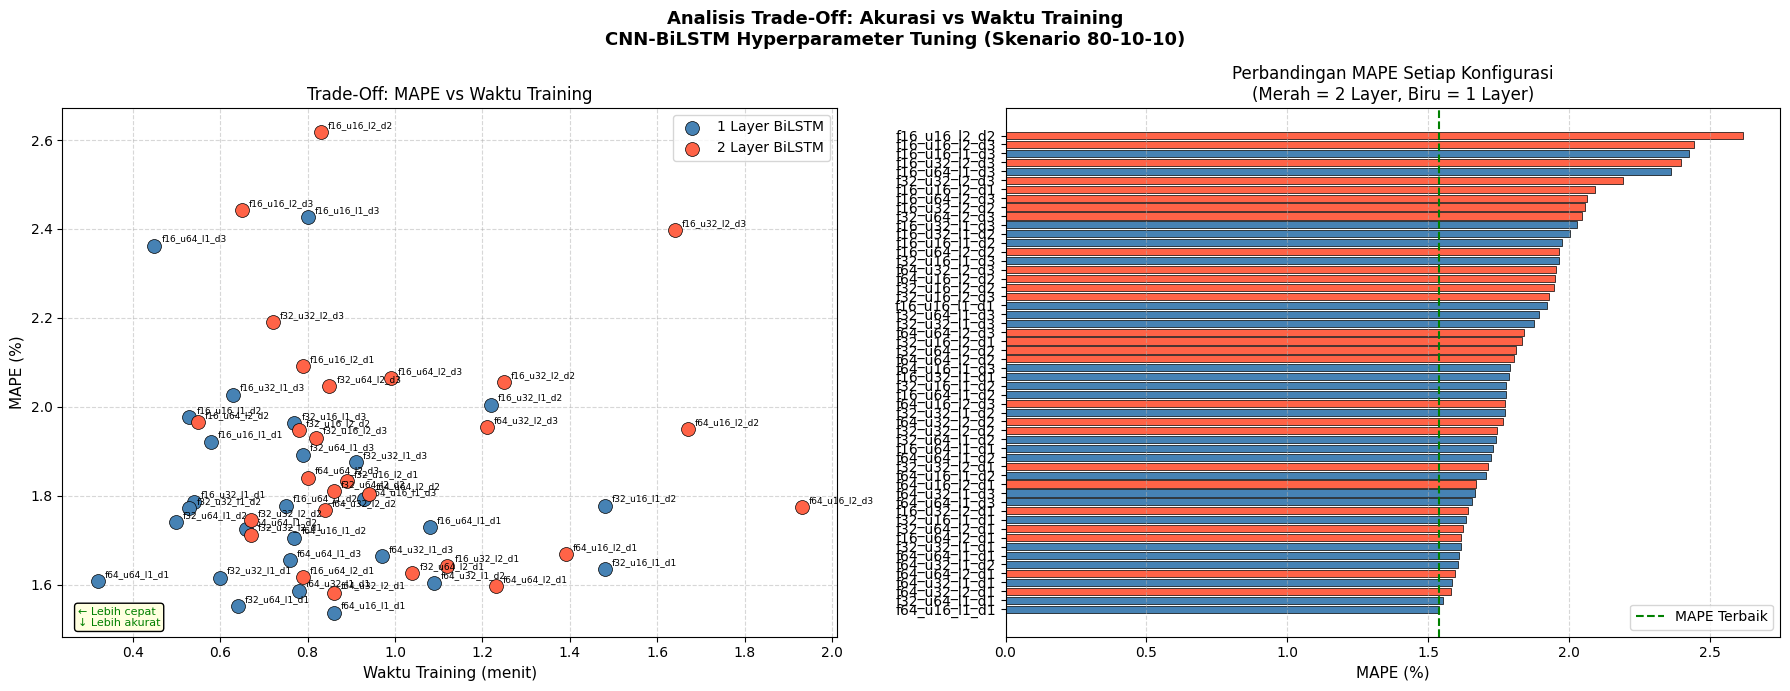


  TOP 3 KONFIGURASI TERBAIK (MAPE terkecil)
         Nama  Filter CNN  Unit BiLSTM  Layer BiLSTM  Dropout  MAPE (%)  Waktu (menit)  Epoch Berhenti
f64_u16_l1_d1          64           16             1      0.1    1.5369           0.86              57
f32_u64_l1_d1          32           64             1      0.1    1.5524           0.64              33
f64_u32_l2_d1          64           32             2      0.1    1.5818           0.86              41

  REKOMENDASI MODEL (Trade-Off Terbaik)
  Konfigurasi  : f64_u64_l1_d1
  Filter CNN   : 64
  Unit BiLSTM  : 64
  Layer BiLSTM : 1
  Dropout      : 0.1
  MAPE         : 1.6086%
  Waktu        : 0.32 menit


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Analisis Trade-Off: Akurasi vs Waktu Training\n'
    'CNN-BiLSTM Hyperparameter Tuning (Skenario 80-10-10)',
    fontsize=13, fontweight='bold'
)

# --- PLOT 1: Scatter MAPE vs Waktu ---
colors_layer = {1: 'steelblue', 2: 'tomato'}
for n_layer in [1, 2]:
    subset = df_tuning[df_tuning['Layer BiLSTM'] == n_layer]
    axes[0].scatter(
        subset['Waktu (menit)'], subset['MAPE (%)'],
        c=colors_layer[n_layer], label=f'{n_layer} Layer BiLSTM',
        s=100, edgecolors='black', linewidths=0.5, zorder=3
    )
    for _, row in subset.iterrows():
        axes[0].annotate(
            row['Nama'],
            (row['Waktu (menit)'], row['MAPE (%)']),
            textcoords='offset points', xytext=(5, 3), fontsize=6.5
        )

axes[0].set_xlabel('Waktu Training (menit)', fontsize=11)
axes[0].set_ylabel('MAPE (%)', fontsize=11)
axes[0].set_title('Trade-Off: MAPE vs Waktu Training')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].annotate(
    '← Lebih cepat\n↓ Lebih akurat',
    xy=(0.02, 0.02), xycoords='axes fraction', fontsize=8, color='green',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow')
)

# --- PLOT 2: Bar MAPE per konfigurasi ---
df_sorted = df_tuning.sort_values('MAPE (%)')
bar_colors = ['tomato' if l == 2 else 'steelblue' for l in df_sorted['Layer BiLSTM']]

axes[1].barh(
    df_sorted['Nama'], df_sorted['MAPE (%)'],
    color=bar_colors, edgecolor='black', linewidth=0.5
)
axes[1].set_xlabel('MAPE (%)', fontsize=11)
axes[1].set_title('Perbandingan MAPE Setiap Konfigurasi\n(Merah = 2 Layer, Biru = 1 Layer)')
axes[1].axvline(
    df_sorted['MAPE (%)'].min(), color='green',
    linestyle='--', linewidth=1.5, label='MAPE Terbaik'
)
axes[1].legend()
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('tradeoff_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Top 3 & Rekomendasi ---
print("\n" + "=" * 70)
print("  TOP 3 KONFIGURASI TERBAIK (MAPE terkecil)")
print("=" * 70)
print(df_tuning.sort_values('MAPE (%)').head(3)[
    ['Nama', 'Filter CNN', 'Unit BiLSTM', 'Layer BiLSTM',
     'Dropout', 'MAPE (%)', 'Waktu (menit)', 'Epoch Berhenti']
].to_string(index=False))

# Rekomendasi: MAPE dalam toleransi 0.5% dari terbaik, pilih paling cepat
mape_terbaik = df_tuning['MAPE (%)'].min()
kandidat     = df_tuning[df_tuning['MAPE (%)'] <= mape_terbaik + 0.5]
rekomendasi  = kandidat.sort_values('Waktu (menit)').iloc[0]

print("\n" + "=" * 70)
print("  REKOMENDASI MODEL (Trade-Off Terbaik)")
print("=" * 70)
print(f"  Konfigurasi  : {rekomendasi['Nama']}")
print(f"  Filter CNN   : {int(rekomendasi['Filter CNN'])}")
print(f"  Unit BiLSTM  : {int(rekomendasi['Unit BiLSTM'])}")
print(f"  Layer BiLSTM : {int(rekomendasi['Layer BiLSTM'])}")
print(f"  Dropout      : {rekomendasi['Dropout']}")
print(f"  MAPE         : {rekomendasi['MAPE (%)']}%")
print(f"  Waktu        : {rekomendasi['Waktu (menit)']} menit")

## CELL 8 — Training Final: 2 Konfigurasi Terpilih × 3 Skenario

Setelah tuning, ambil 2 konfigurasi terbaik (akurasi terbaik & efisiensi terbaik)
lalu jalankan di semua skenario pembagian data.

**Alur per model:**
```
Data → [Train] → Model Terbangun → [Val: monitor EarlyStopping] → [Test] → Performa
```
Performa yang dilaporkan (MAE, RMSE, MAPE) diambil dari **test set**.

In [8]:
os.makedirs('models', exist_ok=True)

# =============================================================
# SESUAIKAN 2 konfigurasi ini berdasarkan hasil tuning Cell 5
# Contoh di bawah menggunakan placeholder — ganti dengan nama
# konfigurasi aktual dari df_tuning setelah tuning selesai.
# =============================================================
top_sorted    = df_tuning.sort_values('MAPE (%)')
best_accuracy = top_sorted.iloc[0]   # MAPE terkecil

# Efisiensi terbaik: MAPE dalam toleransi 0.5%, waktu tercepat
kandidat_efisien = top_sorted[top_sorted['MAPE (%)'] <= best_accuracy['MAPE (%)'] + 0.5]
best_efficient   = kandidat_efisien.sort_values('Waktu (menit)').iloc[0]

konfigurasi_final = [
    {
        'nama'           : best_accuracy['Nama'],
        'label'          : 'Akurasi Terbaik',
        'n_filters'      : int(best_accuracy['Filter CNN']),
        'n_units'        : int(best_accuracy['Unit BiLSTM']),
        'n_bilstm_layers': int(best_accuracy['Layer BiLSTM']),
        'dropout_rate'   : float(best_accuracy['Dropout']),
    },
    {
        'nama'           : best_efficient['Nama'],
        'label'          : 'Efisiensi Terbaik',
        'n_filters'      : int(best_efficient['Filter CNN']),
        'n_units'        : int(best_efficient['Unit BiLSTM']),
        'n_bilstm_layers': int(best_efficient['Layer BiLSTM']),
        'dropout_rate'   : float(best_efficient['Dropout']),
    },
]

skenario_final = ['80-10-10', '70-15-15', '60-20-20']

# Parameter training final (sedikit lebih longgar dari tuning)
EPOCHS_FINAL = 80
BATCH_SIZE   = 32
PATIENCE_FINAL = 10

hasil_final   = []
history_final = {}
model_final   = {}

print("=" * 70)
print("  TRAINING FINAL CNN-BiLSTM")
print(f"  2 Konfigurasi × 3 Skenario = 6 Model")
print("=" * 70)
print(f"  Konfigurasi 1 (Akurasi)   : {konfigurasi_final[0]['nama']}")
print(f"  Konfigurasi 2 (Efisiensi) : {konfigurasi_final[1]['nama']}")

for cfg in konfigurasi_final:
    for nama_skenario in skenario_final:

        key = f"{cfg['nama']}_{nama_skenario}"
        print(f"\n>>> [{key}] | {cfg['label']} | Skenario {nama_skenario}")

        data = datasets[nama_skenario]

        model = bangun_model(
            window_size     = WINDOW_SIZE,
            n_filters       = cfg['n_filters'],
            n_units         = cfg['n_units'],
            n_bilstm_layers = cfg['n_bilstm_layers'],
            dropout_rate    = cfg['dropout_rate'],
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE_FINAL,
            restore_best_weights=True,
            verbose=0
        )
        checkpoint = ModelCheckpoint(
            filepath=f"models/{key}.keras",
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )

        # TRAINING: model belajar dari train, monitor via val
        waktu_mulai = time.time()
        history = model.fit(
            data['X_train'], data['y_train'],
            epochs          = EPOCHS_FINAL,
            batch_size      = BATCH_SIZE,
            validation_data = (data['X_val'], data['y_val']),
            callbacks       = [early_stop, checkpoint],
            verbose         = 0
        )
        durasi = (time.time() - waktu_mulai) / 60
        epoch_berhenti = len(history.history['loss'])

        # EVALUASI PERFORMA: dari TEST SET
        y_pred = model.predict(data['X_test'], verbose=0)
        mae, rmse, mape = hitung_metrik(data['y_test'], y_pred, data['scaler'])

        hasil_final.append({
            'Konfigurasi'   : cfg['nama'],
            'Label'         : cfg['label'],
            'Skenario'      : nama_skenario,
            'Layer BiLSTM'  : cfg['n_bilstm_layers'],
            'Epoch Berhenti': epoch_berhenti,
            'Waktu (menit)' : round(durasi, 2),
            'MAE'           : round(mae, 4),
            'RMSE'          : round(rmse, 4),
            'MAPE (%)'      : round(mape, 4),
        })

        history_final[key] = history.history
        model_final[key]   = model

        print(f"    ✅ Epoch: {epoch_berhenti} | Waktu: {durasi:.2f} mnt | "
              f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4f}%")

df_final_hasil = pd.DataFrame(hasil_final)

print("\n\n" + "=" * 70)
print("  REKAP HASIL TRAINING FINAL")
print("=" * 70)
print(df_final_hasil.to_string(index=False))

df_final_hasil.to_csv('hasil_training_final.csv', index=False)
print("\n✅ Hasil disimpan ke: 'hasil_training_final.csv'")

  TRAINING FINAL CNN-BiLSTM
  2 Konfigurasi × 3 Skenario = 6 Model
  Konfigurasi 1 (Akurasi)   : f64_u16_l1_d1
  Konfigurasi 2 (Efisiensi) : f64_u64_l1_d1

>>> [f64_u16_l1_d1_80-10-10] | Akurasi Terbaik | Skenario 80-10-10


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    ✅ Epoch: 47 | Waktu: 0.49 mnt | MAE: 118.67 | RMSE: 168.66 | MAPE: 1.5495%

>>> [f64_u16_l1_d1_70-15-15] | Akurasi Terbaik | Skenario 70-15-15


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    ✅ Epoch: 58 | Waktu: 0.51 mnt | MAE: 101.65 | RMSE: 150.76 | MAPE: 1.3804%

>>> [f64_u16_l1_d1_60-20-20] | Akurasi Terbaik | Skenario 60-20-20


...

    ✅ Epoch: 38 | Waktu: 0.51 mnt | MAE: 119.02 | RMSE: 169.47 | MAPE: 1.5517%

>>> [f64_u64_l1_d1_70-15-15] | Efisiensi Terbaik | Skenario 70-15-15


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    ✅ Epoch: 43 | Waktu: 0.52 mnt | MAE: 101.11 | RMSE: 146.36 | MAPE: 1.3688%

>>> [f64_u64_l1_d1_60-20-20] | Efisiensi Terbaik | Skenario 60-20-20


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    ✅ Epoch: 57 | Waktu: 0.60 mnt | MAE: 88.64 | RMSE: 130.18 | MAPE: 1.2285%


  REKAP HASIL TRAINING FINAL
  Konfigurasi             Label Skenario  Layer BiLSTM  Epoch Berhenti  Waktu (menit)      MAE     RMSE  MAPE (%)
f64_u16_l1_d1   Akurasi Terbaik 80-10-10             1              47           0.49 118.6663 168.6613    1.5495
f64_u16_l1_d1   Akurasi Terbaik 70-15-15             1              58           0.51 101.6546 150.7633    1.3804
f64_u16_l1_d1   Akurasi Terbaik 60-20-20             1              80           0.62  88.4790 133.7944    1.2263
f64_u64_l1_d1 Efisiensi Terbaik 80-10-10             1              38           0.51 119.0222 169.4680    1.5517
f64_u64_l1_d1 Efisiensi Terbaik 70-15-15             1              43           0.52 101.1074 146.3624    1.3688
f64_u64_l1_d1 Efisiensi Terbaik 60-20-20             1              57           0.60  88.6370 130.1799    1.2285

✅ Hasil disimpan ke: 'hasil_training_final.csv'


## CELL 9 — Loss Curve (Training vs Validation)

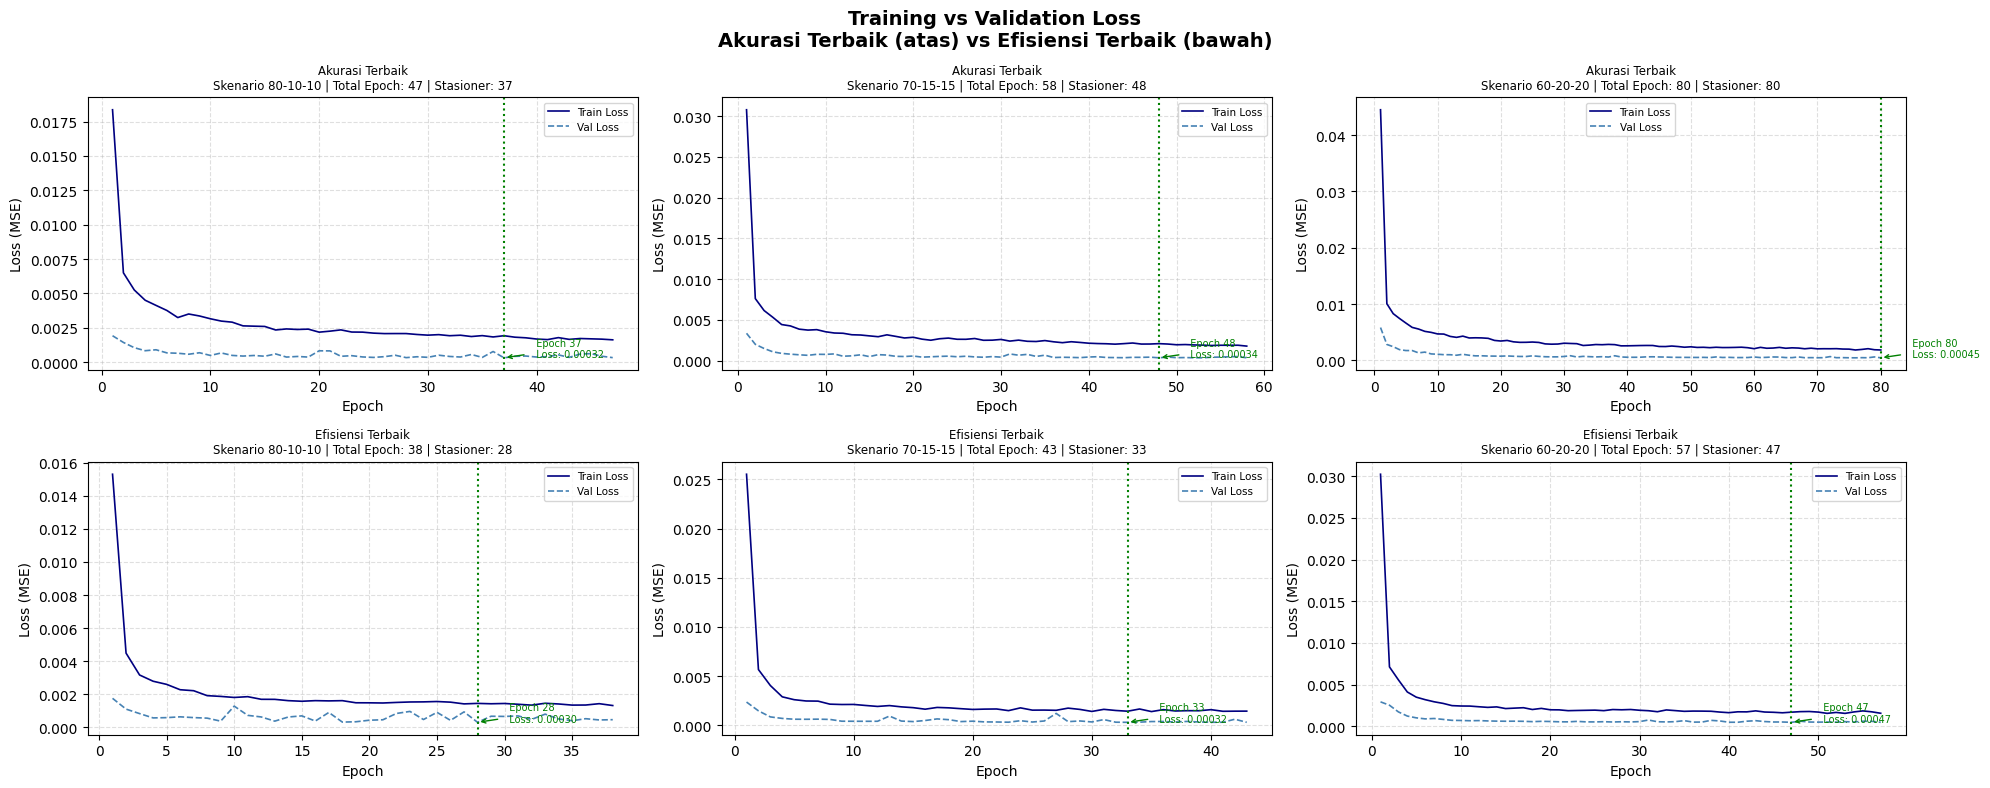

✅ Loss curve disimpan ke: 'loss_curve.png'


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
fig.suptitle(
    'Training vs Validation Loss\n'
    f'{konfigurasi_final[0]["label"]} (atas) vs {konfigurasi_final[1]["label"]} (bawah)',
    fontsize=14, fontweight='bold'
)

for row_idx, cfg in enumerate(konfigurasi_final):
    for col_idx, nama_skenario in enumerate(skenario_final):

        key = f"{cfg['nama']}_{nama_skenario}"
        ax  = axes[row_idx][col_idx]
        h   = history_final[key]

        total_epoch   = len(h['loss'])
        val_loss_arr  = np.array(h['val_loss'])
        best_epoch    = int(np.argmin(val_loss_arr)) + 1
        best_val_loss = val_loss_arr[best_epoch - 1]

        line_color = 'tomato' if cfg['n_bilstm_layers'] == 2 else 'steelblue'

        ax.plot(range(1, total_epoch + 1), h['loss'],
                label='Train Loss', color='navy', linewidth=1.2)
        ax.plot(range(1, total_epoch + 1), h['val_loss'],
                label='Val Loss', color=line_color,
                linewidth=1.2, linestyle='--')

        # Garis vertikal epoch stasioner
        ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5)
        ax.annotate(
            f'  Epoch {best_epoch}\n  Loss: {best_val_loss:.5f}',
            xy=(best_epoch, best_val_loss),
            xytext=(best_epoch + total_epoch * 0.05, best_val_loss * 1.15),
            fontsize=7, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1)
        )

        ax.set_title(
            f"{cfg['label']}\nSkenario {nama_skenario} | "
            f"Total Epoch: {total_epoch} | Stasioner: {best_epoch}",
            fontsize=8.5
        )
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (MSE)')
        ax.legend(fontsize=7.5)
        ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curve disimpan ke: 'loss_curve.png'")

## CELL 10 — Perbandingan Metrik Evaluasi (Bar Chart)

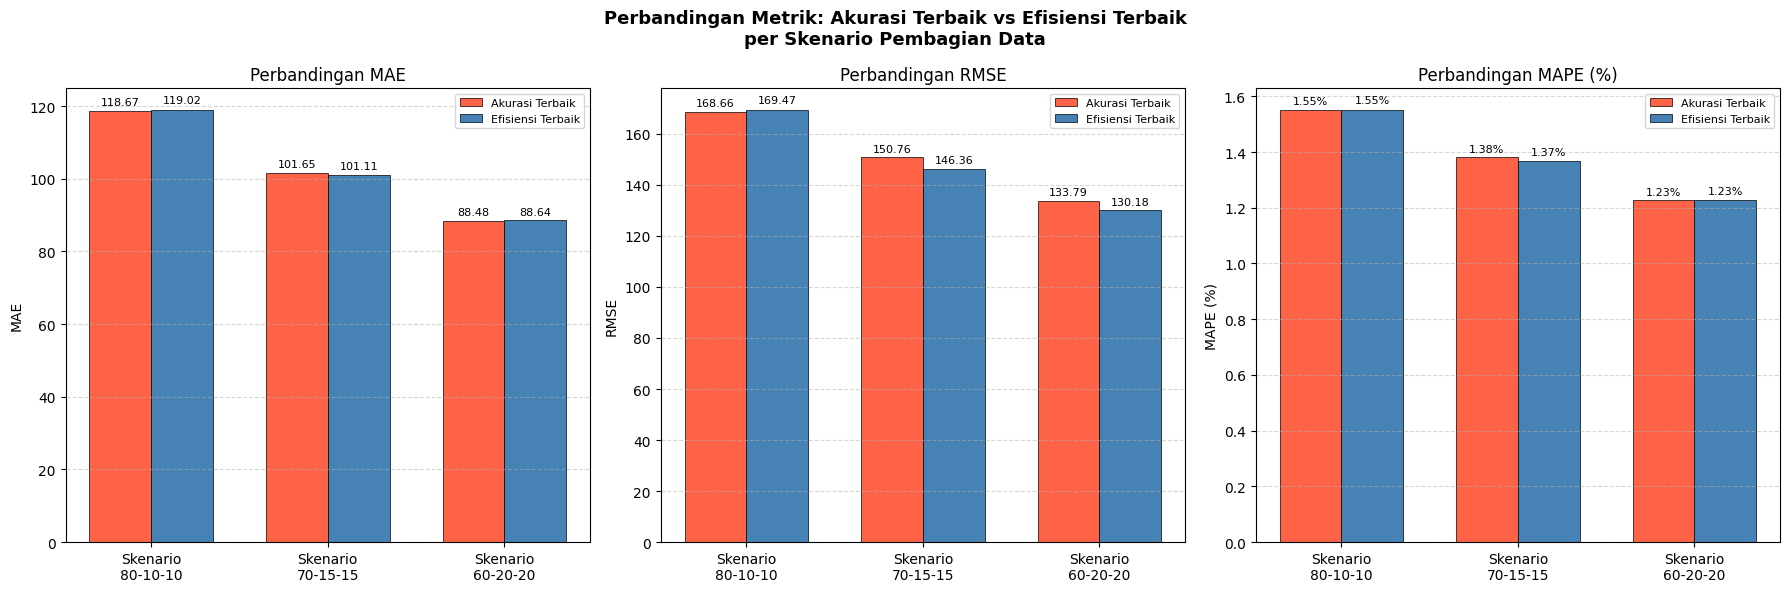


🏆 Model terbaik keseluruhan:
   Konfigurasi : Akurasi Terbaik (f64_u16_l1_d1)
   Skenario    : 60-20-20
   MAE         : 88.48
   RMSE        : 133.79
   MAPE        : 1.2263%
   Waktu       : 0.62 menit


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'Perbandingan Metrik: {konfigurasi_final[0]["label"]} vs {konfigurasi_final[1]["label"]}\n'
    'per Skenario Pembagian Data',
    fontsize=13, fontweight='bold'
)

metrik_list  = ['MAE', 'RMSE', 'MAPE (%)']
metrik_label = ['MAE', 'RMSE', 'MAPE (%)']

label_cfg0 = konfigurasi_final[0]['label']
label_cfg1 = konfigurasi_final[1]['label']
layer_cfg0 = konfigurasi_final[0]['n_bilstm_layers']

for i, (metrik, label) in enumerate(zip(metrik_list, metrik_label)):
    ax    = axes[i]
    x     = np.arange(len(skenario_final))
    width = 0.35

    val_cfg0 = df_final_hasil[df_final_hasil['Label'] == label_cfg0][metrik].values
    val_cfg1 = df_final_hasil[df_final_hasil['Label'] == label_cfg1][metrik].values

    bars0 = ax.bar(x - width/2, val_cfg0, width, label=label_cfg0,
                   color='tomato', edgecolor='black', linewidth=0.5)
    bars1 = ax.bar(x + width/2, val_cfg1, width, label=label_cfg1,
                   color='steelblue', edgecolor='black', linewidth=0.5)

    for bar in list(bars0) + list(bars1):
        val = bar.get_height()
        txt = f'{val:.2f}%' if metrik == 'MAPE (%)' else f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.01 * val,
                txt, ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([f'Skenario\n{s}' for s in skenario_final])
    ax.set_ylabel(label)
    ax.set_title(f'Perbandingan {label}')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('evaluasi_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan
best_row = df_final_hasil.loc[df_final_hasil['MAPE (%)'].idxmin()]
print(f"\n🏆 Model terbaik keseluruhan:")
print(f"   Konfigurasi : {best_row['Label']} ({best_row['Konfigurasi']})")
print(f"   Skenario    : {best_row['Skenario']}")
print(f"   MAE         : {best_row['MAE']:.2f}")
print(f"   RMSE        : {best_row['RMSE']:.2f}")
print(f"   MAPE        : {best_row['MAPE (%)']}%")
print(f"   Waktu       : {best_row['Waktu (menit)']} menit")

## CELL 11 — Visualisasi Prediksi vs Aktual (1 Grafik Terbaik)

**Revisi:** Hanya menampilkan 1 grafik dari model dengan MAPE terkecil,
bukan semua 6 kombinasi.

Model terbaik: f64_u16_l1_d1_60-20-20
MAPE: 1.2263% | MAE: 88.48 | RMSE: 133.79


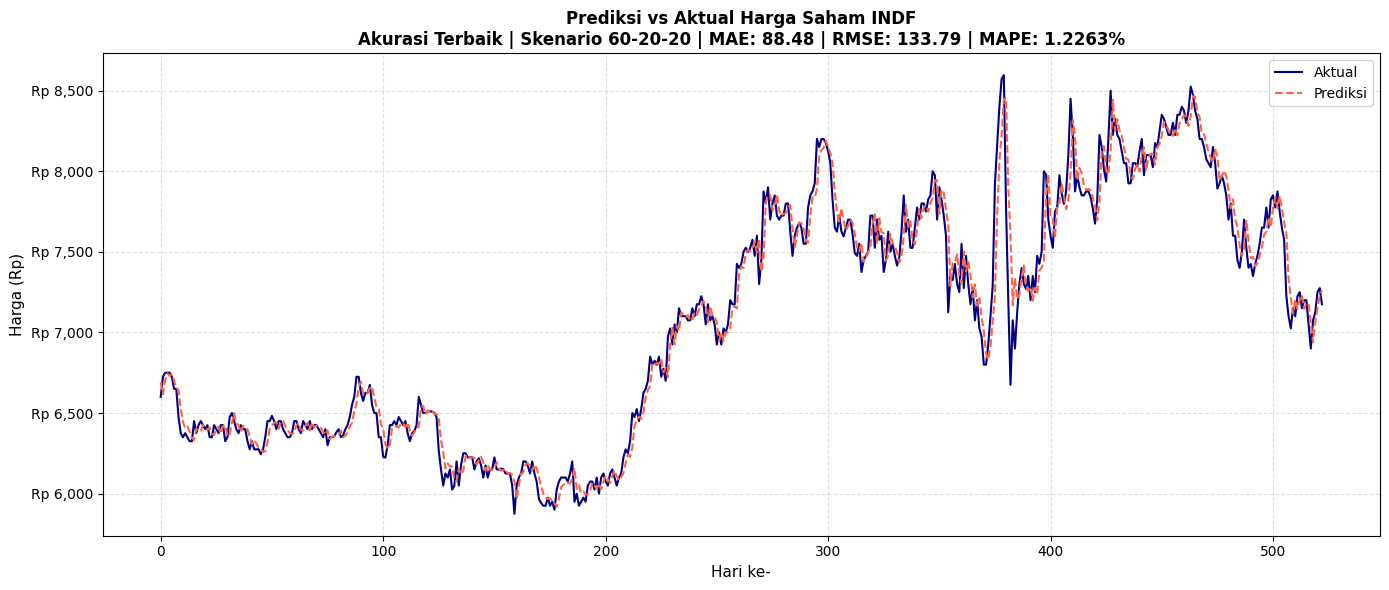

✅ Grafik prediksi disimpan ke: 'prediksi_vs_aktual_terbaik.png'


In [11]:
# Temukan model terbaik
best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_key      = f"{best_row['Konfigurasi']}_{best_row['Skenario']}"
best_skenario = best_row['Skenario']
best_label    = best_row['Label']
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']

print(f"Model terbaik: {best_key}")
print(f"MAPE: {best_mape}% | MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f}")

data = datasets[best_skenario]

# Prediksi ulang
y_pred_scaled = model_final[best_key].predict(data['X_test'], verbose=0)

# Inverse transform → satuan Rupiah
y_true = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
y_pred = data['scaler'].inverse_transform(y_pred_scaled).flatten()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_true, label='Aktual', color='navy', linewidth=1.5)
ax.plot(y_pred, label='Prediksi', color='tomato', linewidth=1.5, linestyle='--')

ax.set_title(
    f'Prediksi vs Aktual Harga Saham INDF\n'
    f'{best_label} | Skenario {best_skenario} | '
    f'MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}%',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Hari ke-', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))

plt.tight_layout()
plt.savefig('prediksi_vs_aktual_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi disimpan ke: 'prediksi_vs_aktual_terbaik.png'")